In [1]:
import numpy as np 
np.set_printoptions(precision=4)
rng = np.random.default_rng(1)

import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.optimizer.ilqr_ergodic_pointmass import iLQR_ergodic_pointmass
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 8.0
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['legend.fontsize'] = 15


In [2]:
from scipy.stats import multivariate_normal as mvn
# Define the target distribution
mean1 = np.array([0.35, 0.38])
cov1 = np.array([
    [0.01, 0.004],
    [0.004, 0.01]
])
w1 = 0.5

mean2 = np.array([0.68, 0.25])
cov2 = np.array([
    [0.005, -0.003],
    [-0.003, 0.005]
])
w2 = 0.2

mean3 = np.array([0.56, 0.64])
cov3 = np.array([
    [0.008, 0.0],
    [0.0, 0.004]
])
w3 = 0.3

def pdf(x):
    return w1 * mvn.pdf(x, mean1, cov1) + \
           w2 * mvn.pdf(x, mean2, cov2) + \
           w3 * mvn.pdf(x, mean3, cov3)

# Define a 1-by-1 2D search space
L_list = np.array([1.0, 1.0])  # boundaries for each dimension

# Discretize the search space into 100-by-100 mesh grids
grids_x, grids_y = np.meshgrid(
    np.linspace(0, L_list[0], 100),
    np.linspace(0, L_list[1], 100)
)
grids = np.array([grids_x.ravel(), grids_y.ravel()]).T
dx = 1.0 / 99
dy = 1.0 / 99 

In [3]:
# Configure the index vectors
num_k_per_dim = 10
ks_dim1, ks_dim2 = np.meshgrid(
    np.arange(num_k_per_dim), np.arange(num_k_per_dim)
)
ks = np.array([ks_dim1.ravel(), ks_dim2.ravel()]).T

# Pre-processing lambda_k and h_k
lamk_list = np.power(1.0 + np.linalg.norm(ks, axis=1), -3/2.0)
hk_list = np.zeros(ks.shape[0])
for i, k_vec in enumerate(ks):
    fk_vals = np.prod(np.cos(np.pi * k_vec / L_list * grids), axis=1)  
    hk = np.sqrt(np.sum(np.square(fk_vals)) * dx * dy)
    hk_list[i] = hk

# compute the coefficients for the target distribution
phik_list = np.zeros(ks.shape[0])  
pdf_vals = pdf(grids)
for i, (k_vec, hk) in enumerate(zip(ks, hk_list)):
    fk_vals = np.prod(np.cos(np.pi * k_vec / L_list * grids), axis=1)  
    fk_vals /= hk

    phik = np.sum(fk_vals * pdf_vals) * dx * dy 
    phik_list[i] = phik

In [4]:
# Define the optimal control problem 
dt = 0.1 
tsteps = 100
R = np.diag([0.0001, 0.0001, 0.0001, 0.0001])
Q_z = np.diag([0.01, 0.01, 0.01, 0.01])
R_v = np.diag([0.01, 0.01, 0.01, 0.01])

# initialize two robots at different locations
x0 = np.array([
    0.25, 0.25,   # robot 1
    0.75, 0.75    # robot 2
])

# generate a spiral trajectory as the initial control
temp_x_traj = np.array([
    np.linspace(0.0, 0.3, tsteps+1) * np.cos(np.linspace(0.0, 2*np.pi, tsteps+1)),
    np.linspace(0.0, 0.3, tsteps+1) * np.sin(np.linspace(0.0, 2*np.pi, tsteps+1)),
    np.linspace(0.0, 0.3, tsteps+1) * np.cos(np.linspace(0.0, 2*np.pi, tsteps+1) + np.pi),
    np.linspace(0.0, 0.3, tsteps+1) * np.sin(np.linspace(0.0, 2*np.pi, tsteps+1) + np.pi)
]).T
init_u_traj = (temp_x_traj[1:, :] - temp_x_traj[:-1, :]) / dt

In [5]:
trajopt_ergodic_pointmass = iLQR_ergodic_pointmass(
    dt, tsteps, x_dim=4, u_dim=4, Q_z=Q_z, R_v=R_v,
    R=R, ks=ks, L_list=L_list, lamk_list=lamk_list,
    hk_list=hk_list, phik_list=phik_list
)

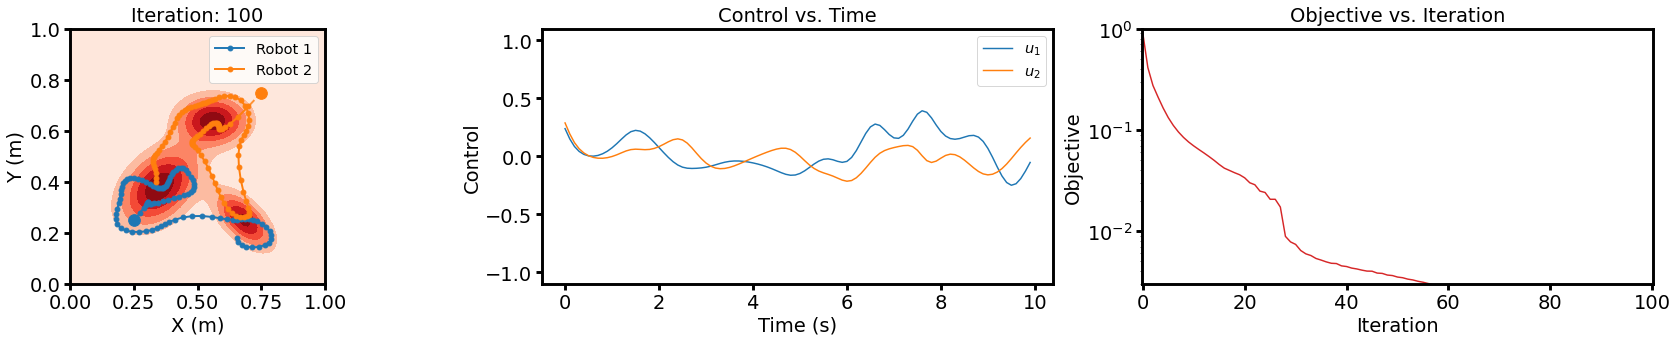

In [6]:
from tqdm import tqdm
# Iterative trajectory optimization for ergodic control
from IPython import display

u_traj = init_u_traj.copy()
step = 0.01
loss_list = []

fig, axes = plt.subplots(1, 3, dpi=70, figsize=(25,5), tight_layout=True)

for iter in tqdm(range(100)):
    x_traj = trajopt_ergodic_pointmass.traj_sim(x0, u_traj)
    v_traj = trajopt_ergodic_pointmass.get_descent(x0, u_traj)

    loss_val = trajopt_ergodic_pointmass.loss(x_traj, u_traj)
    loss_list.append(loss_val)

    step = 0.002
    alpha = 0.5
    for _i in range(3):
        temp_u_traj = u_traj + step * v_traj
        temp_x_traj = trajopt_ergodic_pointmass.traj_sim(x0, temp_u_traj)
        temp_loss_val = trajopt_ergodic_pointmass.loss(temp_x_traj, temp_u_traj)
        if temp_loss_val < loss_val:
            break
        else:
            step *= alpha
    u_traj += step * v_traj

    # visualize every 10 iterations
    if (iter+1) % 10 == 0:
        ax1 = axes[0]
        ax1.cla()
        ax1.set_aspect('equal', adjustable='box')
        ax1.set_xlim(0.0, L_list[0])
        ax1.set_ylim(0.0, L_list[1])
        ax1.set_title('Iteration: {:d}'.format(iter+1))
        ax1.set_xlabel('X (m)')
        ax1.set_ylabel('Y (m)')
        ax1.contourf(grids_x, grids_y, pdf_vals.reshape(grids_x.shape), cmap='Reds')
        
        # =========================
        # Robot 1
        # =========================
        ax1.plot(
            [x0[0], x_traj[0,0]],
            [x0[1], x_traj[0,1]],
            linestyle='--',
            linewidth=2,
            color='C0',
            alpha=0.8
        )

        ax1.plot(
            x_traj[:,0],
            x_traj[:,1],
            linestyle='-',
            marker='o',
            linewidth=2,
            color='C0',
            alpha=1.0,
            label='Robot 1'
        )

        ax1.plot(
            x0[0],
            x0[1],
            linestyle='',
            marker='o',
            markersize=12,
            color='C0',
            alpha=1.0
        )

        # =========================
        # Robot 2
        # =========================
        ax1.plot(
            [x0[2], x_traj[0,2]],
            [x0[3], x_traj[0,3]],
            linestyle='--',
            linewidth=2,
            color='C1',
            alpha=0.8
        )

        ax1.plot(
            x_traj[:,2],
            x_traj[:,3],
            linestyle='-',
            marker='o',
            linewidth=2,
            color='C1',
            alpha=1.0,
            label='Robot 2'
        )

        ax1.plot(
            x0[2],
            x0[3],
            linestyle='',
            marker='o',
            markersize=12,
            color='C1',
            alpha=1.0
        )

        ax1.legend(loc=1)

        ax2 = axes[1]
        ax2.cla()
        ax2.set_title('Control vs. Time')
        ax2.set_ylim(-1.1, 1.1)
        ax2.plot(np.arange(tsteps)*dt, u_traj[:,0], color='C0', label=r'$u_1$')
        ax2.plot(np.arange(tsteps)*dt, u_traj[:,1], color='C1', label=r'$u_2$')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Control')
        ax2.legend(loc=1)
        height = ax1.get_position().height
        ax2.set_position([ax2.get_position().x0, ax1.get_position().y0, ax2.get_position().width, height])

        ax3 = axes[2]
        ax3.cla()
        ax3.set_title('Objective vs. Iteration')
        ax3.set_xlim(-0.2, 100.2)
        ax3.set_ylim(3e-3, 1e0)
        ax3.set_xlabel('Iteration')
        ax3.set_ylabel('Objective')
        ax3.plot(np.arange(iter+1), loss_list, color='C3')
        height = ax1.get_position().height
        ax3.set_position([ax3.get_position().x0, ax1.get_position().y0, ax3.get_position().width, height])
        ax3.set_yscale('log')

        display.clear_output(wait=True)
        display.display(fig)

display.clear_output(wait=True)
plt.show()
plt.close()